# 02 — From Return Forecasts to Risk Budgets: Four Portfolio Constructions on Real Data

**Research question.** *How does portfolio construction change when we move from classical return optimization to uncertainty-aware risk allocation?*

Markowitz (1952) posed portfolio choice as a mean–variance trade-off: given expected returns $\mu$ and covariance $\Sigma$, choose weights $w$ to maximize the Sharpe ratio

$$\max_w \; \frac{w^\top\mu - r_f}{\sqrt{w^\top \Sigma\, w}} \quad \text{s.t.} \quad \mathbf{1}^\top w = 1,\; 0 \le w_i \le 1 .$$

The mathematics is clean; the inputs are not. The sample mean of an asset with annualized volatility $\sigma$ estimated from $Y$ years of data has standard error

$$\operatorname{SE}(\hat\mu) = \frac{\sigma}{\sqrt{Y}},$$

and volatility of daily returns barely helps — only *calendar time* shrinks it (Merton, 1980). With $\sigma \approx 18\%$ and seven years of data, $\operatorname{SE}(\hat\mu) \approx 6.8\%$ *per year* — the same order as the equity risk premium itself. Mean–variance optimization then acts, in Michaud's (1989) phrase, as an **error maximizer**: it leans hardest on the assets whose estimates are most flattered by luck.

This notebook compares four responses to that problem on a real 15-ETF universe (2015–2026):

| Portfolio | Uses $\hat\mu$? | Uses $\hat\Sigma$? | One-line idea |
|---|---|---|---|
| **MVO** (max Sharpe) | yes, at face value | yes, inverted | trust the estimates |
| **Robust MVO** | yes, worst-case in a box $\hat\mu_i \pm u_i$ | yes, inverted | hedge the estimates |
| **Risk parity** | no | yes, not inverted | equalize risk contributions |
| **HRP** | no | correlations only, never inverted | cluster, then split risk |

We fit everything on 2015–2021 and keep 2022–2026 sealed for out-of-sample judgment.

In [1]:
import sys, os, pathlib

ROOT = pathlib.Path.cwd()
if ROOT.name == "notebooks":
    ROOT = ROOT.parent
os.chdir(ROOT)
sys.path.insert(0, str(ROOT))

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

plt.rcParams.update({
    "figure.figsize": (9.5, 5), "figure.dpi": 100,
    "axes.grid": True, "grid.alpha": 0.3,
    "axes.spines.top": False, "axes.spines.right": False,
})
SEED = 42

from src.data.market_data_loader import load_prices, to_returns
from src.portfolio.mean_variance import max_sharpe, efficient_frontier, PortfolioResult
from src.portfolio.risk_parity import risk_parity_weights, risk_contributions
from src.portfolio.hierarchical_risk_parity import hrp_weights
from src.portfolio.robust_optimization import robust_max_sharpe
from src.backtesting.performance_metrics import summary

TICKERS = ["SPY", "QQQ", "IWM", "EFA", "EEM", "AGG", "TLT", "LQD",
           "GLD", "DBC", "VNQ", "USMV", "MTUM", "VLUE", "QUAL"]
prices = load_prices(TICKERS)          # cached snapshot, 2015-01 .. 2026-07
rets = to_returns(prices)
print(f"{rets.shape[0]} daily observations, {rets.index[0].date()} to {rets.index[-1].date()}")

2891 daily observations, 2015-01-05 to 2026-07-06


## 1. The universe and the estimation split

Fifteen liquid ETFs spanning US equity (broad, small-cap, and four style factors), international and emerging equity, three bond sleeves, gold, commodities, and REITs. All statistics below are **annualized from daily data on the in-sample window only** (2015-01 to 2021-12); the out-of-sample window (2022-01 to 2026-07) is not touched until Section 5.

A caveat we will keep repeating: the $\hat\mu$ column of this table is the least trustworthy number in the notebook. Its standard error, shown alongside, is computed as $\hat\sigma/\sqrt{Y}$ with $Y \approx 7$ years — for most equity ETFs the 95% confidence band on the annual mean is roughly $\pm 12$–$16$ percentage points wide.

In [2]:
ins = rets.loc[:"2021-12-31"]
oos = rets.loc["2022-01-01":]
n_years = len(ins) / 252

mu  = ins.mean() * 252
cov = ins.cov() * 252
vol = ins.std() * np.sqrt(252)
mu_se = vol / np.sqrt(n_years)          # standard error of the annualized mean
RF = 0.02

est = pd.DataFrame({"ann. mean": mu, "ann. vol": vol, "SE(mean)": mu_se,
                    "mean / SE": mu / mu_se}).sort_values("ann. mean", ascending=False)
est.round(3)

,ann. mean,ann. vol,SE(mean),mean / SE
QQQ,0.224,0.210,0.079,2.822
MTUM,0.173,0.201,0.076,2.268
SPY,0.154,0.177,0.067,2.308
QUAL,0.154,0.178,0.067,2.294
USMV,0.130,0.152,0.058,2.258
IWM,0.128,0.222,0.084,1.521
VLUE,0.118,0.202,0.076,1.549
VNQ,0.111,0.209,0.079,1.410
EFA,0.082,0.175,0.066,1.237
EEM,0.077,0.215,0.081,0.952


Only a handful of assets have in-sample means more than two standard errors from zero — QQQ most prominently. Every optimizer below sees this same table; they differ in how much of it they believe.

## 2. Four constructions

- **MVO max Sharpe** takes $\hat\mu, \hat\Sigma$ at face value.
- **Robust max Sharpe** maximizes the *worst-case* Sharpe over the box $\mu_i \in [\hat\mu_i - u_i,\, \hat\mu_i + u_i]$, with $u_i = \operatorname{SE}(\hat\mu_i)$ — a one-standard-error haircut on every return forecast, harshest on volatile assets.
- **Risk parity** ignores $\hat\mu$ entirely and solves for equal fractional risk contributions, $\text{RC}_i = w_i (\Sigma w)_i / (w^\top \Sigma w) = 1/N \; \forall i$.
- **HRP** (López de Prado, 2016) never inverts $\Sigma$ at all: it clusters assets by correlation distance, quasi-diagonalizes, and recursively splits the risk budget — robust to the near-singular covariance matrices that 15 correlated assets and finite data produce.

,MVO max Sharpe,Robust MVO,Risk parity,HRP
SPY,0.000,0.000,0.037,0.019
QQQ,0.525,0.918,0.033,0.008
IWM,0.000,0.000,0.032,0.008
EFA,0.000,0.000,0.039,0.013
EEM,0.000,0.000,0.033,0.012
AGG,0.000,0.000,0.217,0.536
TLT,0.359,0.082,0.174,0.064
LQD,0.000,0.000,0.099,0.158
GLD,0.116,0.000,0.090,0.066
DBC,0.000,0.000,0.063,0.030


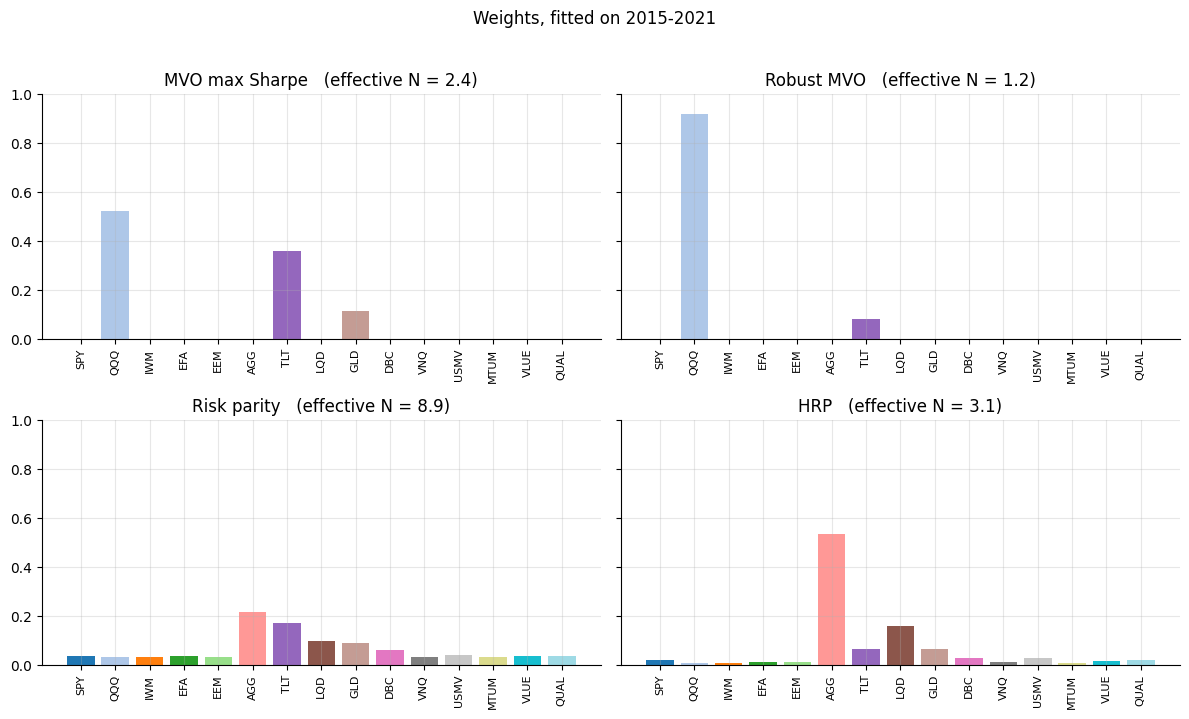

In [3]:
w_mvo = max_sharpe(mu, cov, rf=RF)
w_rob = robust_max_sharpe(mu, cov, mu_uncertainty=mu_se, rf=RF)
w_rp  = risk_parity_weights(cov)
w_hrp = hrp_weights(ins)

def as_result(w, name):
    er = float(w @ mu); v = float(np.sqrt(w @ cov @ w))
    return PortfolioResult(weights=w, expected_return=er, volatility=v, sharpe=(er - RF) / v)

results = {"MVO max Sharpe": w_mvo, "Robust MVO": w_rob,
           "Risk parity": as_result(w_rp, "rp"), "HRP": as_result(w_hrp, "hrp")}

W = pd.DataFrame({k: v.weights for k, v in results.items()}).reindex(TICKERS).fillna(0.0)
eff_n = 1.0 / (W ** 2).sum()

fig, axes = plt.subplots(2, 2, figsize=(12, 7), sharey=True)
colors = plt.cm.tab20(np.linspace(0, 1, len(TICKERS)))
for ax, name in zip(axes.ravel(), W.columns):
    ax.bar(W.index, W[name], color=colors)
    ax.set_title(f"{name}   (effective N = {eff_n[name]:.1f})")
    ax.tick_params(axis="x", rotation=90, labelsize=8)
    ax.set_ylim(0, 1)
fig.suptitle("Weights, fitted on 2015-2021", y=1.02)
plt.tight_layout()
W.round(3)

**Interpretation — and one honest surprise.** MVO does what its critics predict: of fifteen assets it holds three (QQQ, TLT, GLD), an effective breadth of about 2.4 names. The surprise is the **robust** portfolio: far from diversifying, it concentrates *harder* — roughly 92% QQQ. The mechanism is instructive. The worst-case penalty $u_i|w_i|$ scales with each asset's own standard error, so it haircuts *every* return forecast; but QQQ's in-sample premium exceeded its own standard error by more than any other asset's did (the `mean / SE` column above), so after the haircut it looks *relatively even better*. Box-uncertainty robustness hedges the level of $\hat\mu$, not its *ranking* — and it is the ranking that concentrates portfolios.

The genuinely diversified books come from **abandoning $\hat\mu$**, not haircutting it. Risk parity holds all fifteen assets (effective N ≈ 8.9), tilted toward bonds because equalizing risk means underweighting volatility. HRP lands in between (effective N ≈ 3.1 by weight — though, as the next section shows, its *risk* is far better spread than MVO's), with over half the book in AGG because the clustering step isolates the low-vol bond cluster and hands it a large slice of the risk budget.

## 3. Where the risk actually sits

Weights mislead; risk contributions do not. $\text{RC}_i$ is the fraction of portfolio variance attributable to asset $i$, and it is what risk parity equalizes *by construction*.

,MVO max Sharpe,Robust MVO,Risk parity,HRP
SPY,0.000,0.000,0.067,0.031
QQQ,0.859,1.014,0.067,0.015
IWM,0.000,0.000,0.067,0.014
EFA,0.000,0.000,0.067,0.020
EEM,0.000,0.000,0.067,0.022
AGG,0.000,0.000,0.067,0.359
TLT,0.097,-0.014,0.067,0.085
LQD,0.000,0.000,0.067,0.199
GLD,0.044,0.000,0.067,0.084
DBC,0.000,0.000,0.067,0.029


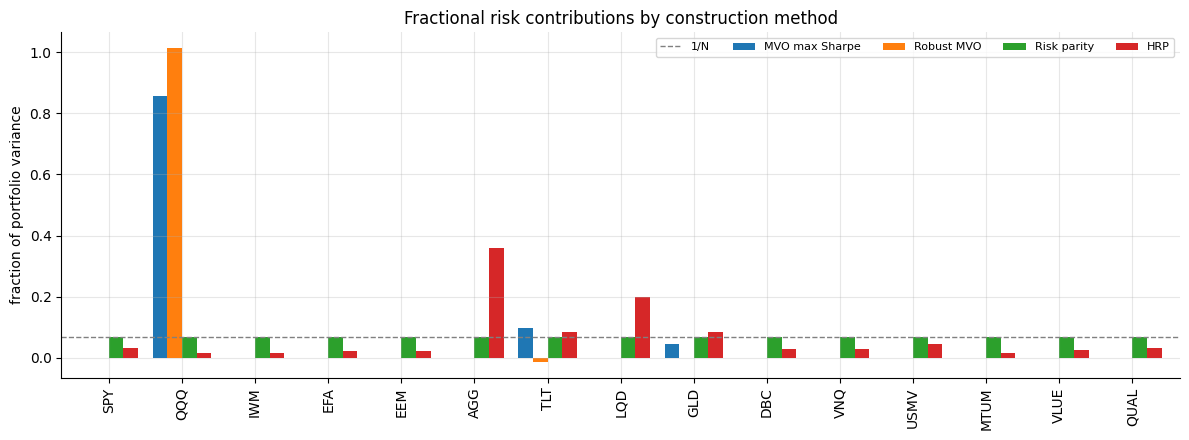

In [4]:
rc = pd.DataFrame({name: risk_contributions(W[name], cov) for name in W.columns})

ax = rc.plot.bar(figsize=(12, 4.5), width=0.8)
ax.axhline(1 / len(TICKERS), color="gray", ls="--", lw=1, label="1/N")
ax.set_ylabel("fraction of portfolio variance")
ax.set_title("Fractional risk contributions by construction method")
ax.legend(fontsize=8, ncol=5)
plt.tight_layout()
rc.round(3)

**Interpretation.** The MVO and robust books derive essentially all of their variance from one or two positions — a single-factor bet wearing a fifteen-asset universe as a costume. Risk parity's bars sit on the $1/N$ line by construction. HRP is not exactly flat (it never promised to be) but spreads variance across clusters rather than names. If a risk committee asked "what are we actually exposed to?", only the right two portfolios have an answer longer than one ticker.

## 4. The efficient frontier, with everyone on the map

The frontier is computed from the same in-sample $(\hat\mu, \hat\Sigma)$, so MVO *must* sit on it and the risk-based portfolios *must* plot inside it — in-sample, ignoring $\hat\mu$ is always "inefficient." The interesting question is whether that in-sample sacrifice buys anything out of sample.

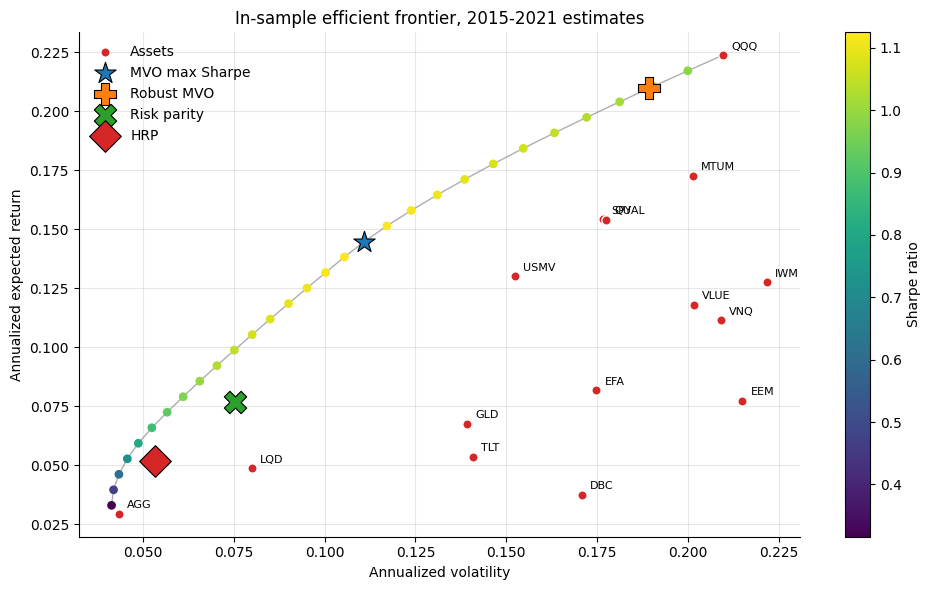

In [5]:
from src.visualization.efficient_frontier import plot_efficient_frontier

frontier = efficient_frontier(mu, cov, n_points=30, rf=RF)
fig = plot_efficient_frontier(frontier, assets_mu=mu, assets_vol=vol, highlight=results)
fig.set_size_inches(10, 6)
fig.axes[0].set_title("In-sample efficient frontier, 2015-2021 estimates")
plt.tight_layout()

## 5. Out-of-sample: the sealed envelope

We now apply the four weight vectors — frozen at their 2021-12 values — to daily returns from 2022-01 through 2026-07. This is a deliberately simple protocol (no rebalancing, no transaction costs; notebook 06 does the cost-aware version) so that the only thing being tested is the *quality of the weights*.

The window is an interesting stress: 2022 delivered a joint equity–bond drawdown that punished exactly the stock/bond diversification that 2015–2021 data recommends, followed by an AI-led mega-cap rally that rewarded concentration in QQQ.

In [6]:
oos_perf = pd.DataFrame({name: summary(oos @ W[name], rf=RF) for name in W.columns})
ins_perf = pd.DataFrame({name: summary(ins @ W[name], rf=RF) for name in W.columns})

comparison = pd.concat({"in-sample 2015-2021": ins_perf,
                        "out-of-sample 2022-2026": oos_perf}, axis=1)
comparison.round(3)

in-sample 2015-2021                                 \
                       MVO max Sharpe Robust MVO Risk parity     HRP   
annualized_return               0.148      0.211       0.077   0.052   
annualized_vol                  0.111      0.189       0.075   0.053   
sharpe_ratio                    1.125      1.002       0.756   0.599   
sortino_ratio                   1.591      1.405       1.019   0.798   
calmar_ratio                    1.057      0.827       0.460   0.397   
hit_rate                        0.575      0.573       0.567   0.553   
max_drawdown                    0.140      0.255       0.167   0.130   
skew                           -0.472     -0.517      -1.547  -2.358   
kurtosis                        5.767      8.993      23.582  43.740   
VaR95                           0.011      0.019       0.006   0.004   
ES95                            0.017      0.029       0.011   0.007   

                  out-of-sample 2022-2026                                
                           MVO max Sharpe Robust MVO Risk parity    HRP  
annualized_return                   0.076      0.132       0.050  0.026  
annualized_vol                      0.146      0.217       0.094  0.073  
sharpe_ratio                        0.435      0.587       0.355  0.121  
sortino_ratio                       0.628      0.844       0.505  0.170  
calmar_ratio                        0.249      0.383       0.248  0.147  
hit_rate                            0.517      0.546       0.538  0.527  
max_drawdown                        0.304      0.343       0.202  0.180  
skew                                0.240      0.203       0.125  0.068  
kurtosis                            4.349      4.965       3.563  2.349  
VaR95                               0.016      0.022       0.010  0.007  
ES95                                0.020      0.031       0.013  0.010

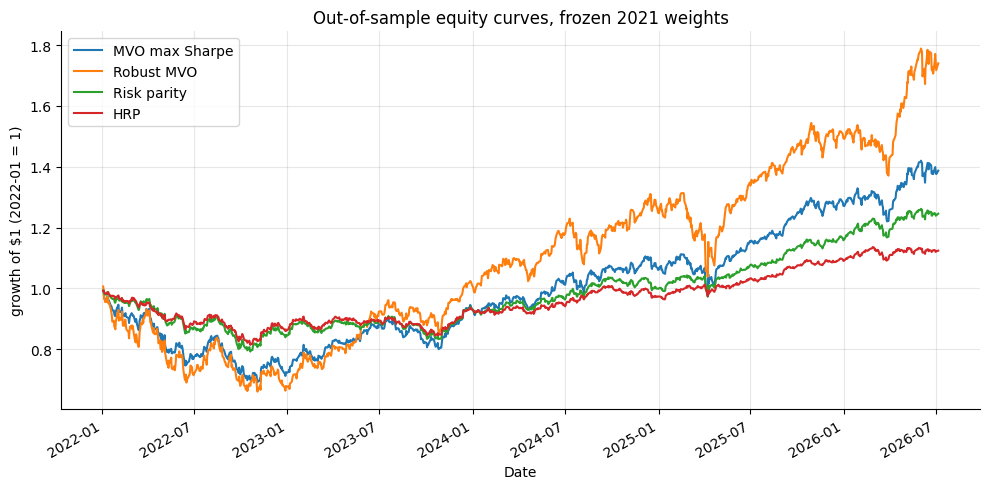

In [7]:
oos_curves = (1 + pd.DataFrame({n: oos @ W[n] for n in W.columns})).cumprod()
ax = oos_curves.plot(figsize=(10, 5))
ax.set_ylabel("growth of $1 (2022-01 = 1)")
ax.set_title("Out-of-sample equity curves, frozen 2021 weights")
plt.tight_layout()

**Interpretation.** Read the Sharpe rows first. In-sample, MVO wins by construction (≈ 1.1); out of sample it roughly *halves* (≈ 0.4) — the textbook signature of estimation error being harvested in-sample and repaid out-of-sample. The robust portfolio posts the best out-of-sample Sharpe (≈ 0.6), but for an uncomfortable reason: its QQQ concentration happened to ride the 2023–2025 mega-cap rally. One should be very hesitant to call that vindication — the same book drew down over 30% in 2022, and a single 4.5-year window cannot distinguish skill from a lucky regime.

The risk-based portfolios kept their promises on the *risk* side and disappointed on the return side. Both ran at roughly half the volatility (7–9% vs 15–22%) and two-thirds the drawdown (18–20% vs 30–34%) of the optimized books. But their out-of-sample Sharpes (≈ 0.1–0.4) were hurt by the one thing they structurally overweight — bonds — in the one period since 1981 when bonds crashed alongside equities. HRP, the most bond-heavy, suffered most.

Three lessons, none triumphant:

1. **In-sample Sharpe is an advertisement, not a forecast.** Every method degraded out of sample; the ranking reshuffled.
2. **Estimation error is the villain, but robustness is not automatically the hero.** Haircutting $\hat\mu$ symmetrically preserved the concentration; only dropping $\hat\mu$ diversified. What risk-based methods actually deliver — reliably — is the *risk* profile, not the return profile.
3. **Every allocation is a regime bet in disguise.** Risk parity's bond tilt is a bet that stock–bond correlation stays negative; 2022 called it. There is no construction method without an embedded assumption — only methods whose assumptions are cheaper to state.

## Limitations

- **One out-of-sample window is one draw.** A serious study would use rolling-origin evaluation across many windows and report the *distribution* of out-of-sample Sharpes, not a point estimate per method.
- **Frozen weights favor no one consistently** but are unrealistic; costs, rebalancing, and drift are handled properly in notebook 06.
- **The universe itself is survivorship-tilted**: these fifteen ETFs exist, are liquid, and were chosen in 2026 — an easy, invisible form of look-ahead.
- **Covariance was taken raw.** Ledoit–Wolf shrinkage (available in `src.math.numerical_linear_algebra`) would likely improve every $\Sigma$-dependent method; we kept inputs identical across methods to isolate the construction step.
- Sharpe differences of ±0.2 over 4.5 years are far inside sampling noise (the SE of a Sharpe estimate over $Y$ years is roughly $\sqrt{(1+\text{SR}^2/2)/Y} \approx 0.5$ here).

Models clarify uncertainty; they do not eliminate it. Here the honest summary is: we know with confidence what risk parity and HRP will *hold* and roughly how they will *behave*; we know with very little confidence which method will post the best Sharpe over the next five years.